In [ ]:
#before running this please change the RUNTIME to GPU (Runtime -> Change runtime type -> set harware accelarotor as GPU)
#Mount our google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip3 install face_recognition

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=4e61a2b8cc468cab4bf58b2b7842bd07d107b18fca25d10591603350859b9c5d
  Stored in directory: /root/.cache/pip/wheels/39/20/47/6b647a3457f0e36c161b2516a5bd7f29f6bbd5e3a67c46a710
Successfully built face-recognition-models


In [ ]:
import glob
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Dataset
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import face_recognition

# Check if the file is corrupted or not
def validate_video(vid_path, train_transforms):

    transform = train_transforms
    count = 20
    frames = []

    for frame in frame_extract(vid_path):

        if frame is None:
            continue

        frames.append(transform(frame))

        if len(frames) == count:
            break

    # Si no hay frames válidos => video corrupto
    if len(frames) == 0:
        raise ValueError("No valid frames")

    frames = torch.stack(frames)
    frames = frames[:count]

    return frames


# Extract frames from video
def frame_extract(path):

    vidObj = cv2.VideoCapture(path)

    if not vidObj.isOpened():
        raise ValueError("Cannot open video")

    success = True

    while success:

        success, image = vidObj.read()

        if success and image is not None:
            yield image

    vidObj.release()


im_size = 112

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((im_size, im_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

video_fil = glob.glob('/content/drive/MyDrive/FINAL_DATASET/ia/frames/*.mp4')
video_fil += glob.glob('/content/drive/MyDrive/FINAL_DATASET/real/frames/*.mp4')

print("Total no of videos:", len(video_fil))

count = 0
deleted = 0

for i in video_fil:

    try:
        count += 1

        validate_video(i, train_transforms)

    except Exception as e:

        print("\nCorrupted video:", i)
        print("Error:", e)

        # Eliminar video corrupto
        try:
            os.remove(i)
            deleted += 1
            print("Deleted:", i)

        except Exception as delete_error:
            print("Could not delete:", delete_error)

print("\nProcessed videos:", count)
print("Deleted corrupted videos:", deleted)

Total no of videos: 376

Processed videos: 376
Deleted corrupted videos: 0


In [ ]:
#to load preprocessod video to memory
import json
import glob
import numpy as np
import cv2
import copy
import random
video_files =  glob.glob('/content/drive/MyDrive/FINAL_DATASET/ia/frames/*.mp4')
video_files += glob.glob('/content/drive/MyDrive/FINAL_DATASET/real/frames/*.mp4')

random.shuffle(video_files)
random.shuffle(video_files)
frame_count = []
for video_file in video_files:
  cap = cv2.VideoCapture(video_file)
  if(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))<100):
    video_files.remove(video_file)
    continue
  frame_count.append(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
print("frames are " , frame_count)
print("Total no of video: " , len(frame_count))
print('Average frame per video:',np.mean(frame_count))

frames are  [148, 142, 148, 148, 148, 148, 148, 148, 148, 148, 105, 148, 148, 148, 148, 127, 148, 147, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 126, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 118, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 144, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 125, 148, 141, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 109, 148, 145, 145, 147, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 146, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 143, 148, 148, 148, 148, 148, 148, 148, 148, 148, 133, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 122, 14

In [ ]:
# load the video name and labels from csv
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Dataset
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import face_recognition
class video_dataset(Dataset):
    def __init__(self,video_names,labels,sequence_length = 60,transform = None):
        self.video_names = video_names
        self.labels = labels
        self.transform = transform
        self.count = sequence_length
    def __len__(self):
        return len(self.video_names)
    def __getitem__(self,idx):
        video_path = self.video_names[idx]
        frames = []
        a = int(100/self.count)
        first_frame = np.random.randint(0,a)
        temp_video = video_path.split('/')[-1]
        #print(temp_video)
        label = self.labels.iloc[(labels.loc[labels["file"] == temp_video].index.values[0]),1]
        if(label == 'FAKE'):
          label = 0
        if(label == 'REAL'):
          label = 1
        for i,frame in enumerate(self.frame_extract(video_path)):
          frames.append(self.transform(frame))
          if(len(frames) == self.count):
            break
        frames = torch.stack(frames)
        frames = frames[:self.count]
        #print("length:" , len(frames), "label",label)
        return frames,label
    def frame_extract(self,path):
      vidObj = cv2.VideoCapture(path)
      success = 1
      while success:
          success, image = vidObj.read()
          if success:
              yield image
#plot the image
def im_plot(tensor):
    image = tensor.cpu().numpy().transpose(1,2,0)
    b,g,r = cv2.split(image)
    image = cv2.merge((r,g,b))
    image = image*[0.22803, 0.22145, 0.216989] +  [0.43216, 0.394666, 0.37645]
    image = image*255.0
    plt.imshow(image.astype(int))
    plt.show()

In [ ]:
#count the number of fake and real videos
def number_of_real_and_fake_videos(data_list):
  header_list = ["file","label"]
  lab = pd.read_csv('/content/drive/MyDrive/FINAL_DATASET/global_metadata.csv',names=header_list)
  fake = 0
  real = 0
  for i in data_list:
    temp_video = i.split('/')[-1]
    label = lab.iloc[(labels.loc[labels["file"] == temp_video].index.values[0]),1]
    if(label == 'FAKE'):
      fake+=1
    if(label == 'REAL'):
      real+=1
  return real,fake

train :  292
test :  74
TRAIN:  Real: 143  Fake: 149


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


TEST:  Real: 37  Fake: 37


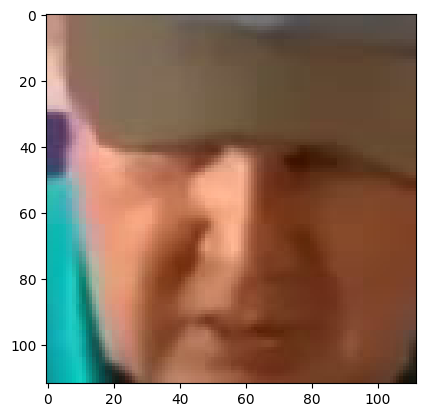

In [ ]:
# load the labels and video in data loader
import random
import pandas as pd
from sklearn.model_selection import train_test_split

header_list = ["file","label"]
labels = pd.read_csv('/content/drive/MyDrive/FINAL_DATASET/global_metadata_clean.csv',names=header_list)
#print(labels)
train_videos = video_files[:int(0.8*len(video_files))]
valid_videos = video_files[int(0.8*len(video_files)):]
print("train : " , len(train_videos))
print("test : " , len(valid_videos))
# train_videos,valid_videos = train_test_split(data,test_size = 0.2)
# print(train_videos)

print("TRAIN: ", "Real:",number_of_real_and_fake_videos(train_videos)[0]," Fake:",number_of_real_and_fake_videos(train_videos)[1])
print("TEST: ", "Real:",number_of_real_and_fake_videos(valid_videos)[0]," Fake:",number_of_real_and_fake_videos(valid_videos)[1])


im_size = 112
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
                                        transforms.ToPILImage(),
                                        transforms.Resize((im_size,im_size)),
                                        transforms.ToTensor(),
                                        transforms.Normalize(mean,std)])

test_transforms = transforms.Compose([
                                        transforms.ToPILImage(),
                                        transforms.Resize((im_size,im_size)),
                                        transforms.ToTensor(),
                                        transforms.Normalize(mean,std)])
train_data = video_dataset(train_videos,labels,sequence_length = 10,transform = train_transforms)
#print(train_data)
val_data = video_dataset(valid_videos,labels,sequence_length = 10,transform = train_transforms)
train_loader = DataLoader(train_data,batch_size = 4,shuffle = True,num_workers = 4)
valid_loader = DataLoader(val_data,batch_size = 4,shuffle = True,num_workers = 4)
image,label = train_data[0]
im_plot(image[0,:,:,:])

In [ ]:
import os
import pandas as pd

print("Videos encontrados físicamente:", len(video_files))
print("Registros en CSV:", len(labels))

print("\nPrimeras filas del CSV:")
print(labels.head())

print("\nValores nulos:")
print(labels.isnull().sum())

Videos encontrados físicamente: 366
Registros en CSV: 366

Primeras filas del CSV:
                                                file label
0   real_tk_ssstik.io_@josejeriore_1770523934394.mp4  REAL
1  real_tk_ssstik.io_@keikofujimorih_177052403007...  REAL
2  real_tk_ssstik.io_@rafael_lopez_aliaga_1770524...  REAL
3   real_tk_ssstik.io_@cesaracunap_1770524242654.mp4  REAL
4  real_tk_ssstik.io_@alfonso.lopezchau_177052434...  REAL

Valores nulos:
file     0
label    0
dtype: int64


In [ ]:
video_names = [os.path.basename(video) for video in video_files]

csv_names = labels["file"].astype(str).tolist()

missing_in_disk = [
    name for name in csv_names
    if name not in video_names
]

missing_in_csv = [
    name for name in video_names
    if name not in csv_names
]

print("Archivos del CSV que NO están en video_files:",
      len(missing_in_disk))

print("Archivos físicos que NO están en el CSV:",
      len(missing_in_csv))

print("\nEjemplos faltantes en disco:")
print(missing_in_disk[:10])

print("\nEjemplos faltantes en CSV:")
print(missing_in_csv[:10])

Archivos del CSV que NO están en video_files: 0
Archivos físicos que NO están en el CSV: 0

Ejemplos faltantes en disco:
[]

Ejemplos faltantes en CSV:
[]


In [ ]:
#Model with feature visualization
from torch import nn
from torchvision import models
class Model(nn.Module):
    def __init__(self, num_classes,latent_dim= 2048, lstm_layers=1 , hidden_dim = 2048, bidirectional = False):
        super(Model, self).__init__()
        model = models.resnext50_32x4d(pretrained = True) #Residual Network CNN
        self.model = nn.Sequential(*list(model.children())[:-2])
        self.lstm = nn.LSTM(latent_dim,hidden_dim, lstm_layers,  bidirectional)
        self.relu = nn.LeakyReLU()
        self.dp = nn.Dropout(0.4)
        self.linear1 = nn.Linear(2048,num_classes)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
    def forward(self, x):
        batch_size,seq_length, c, h, w = x.shape
        x = x.view(batch_size * seq_length, c, h, w)
        fmap = self.model(x)
        x = self.avgpool(fmap)
        x = x.view(batch_size,seq_length,2048)
        x_lstm,_ = self.lstm(x,None)
        return fmap,self.dp(self.linear1(torch.mean(x_lstm,dim = 1)))

El modelo que has definido (`Model`) está diseñado para clasificar videos como 'Fake' (0) o 'Real' (1).

Al momento de la predicción, específicamente en el método `forward` de la clase `Model` y en la función `test`, el modelo retorna dos valores:

1.  **`fmap`**: Este es el *feature map* (mapa de características) obtenido de la capa convolucional (`self.model`, que es una ResNeXt). Representa una representación visual de alto nivel extraída del video.
2.  **`self.dp(self.linear1(torch.mean(x_lstm,dim = 1)))`**: Este es el valor más relevante para la clasificación. Es el resultado de la capa lineal final (`self.linear1`), que toma las características procesadas por la LSTM y las proyecta en un espacio de dos dimensiones (ya que `num_classes` es 2).
    *   Estos dos valores son **logits** (puntuaciones logarítmicas en bruto), uno para la clase 'Fake' y otro para la clase 'Real'. No son directamente probabilidades, sino una medida de la confianza del modelo en cada clase.

**¿Cómo se interpretan estos logits?**

*   Para obtener la clase predicha, se selecciona la clase con el *logit* más alto. Por ejemplo, si los logits son `[0.5, -0.2]`, el modelo predice la primera clase (Fake) porque 0.5 es mayor que -0.2.
*   Para obtener las **probabilidades** de cada clase (como se hace en la celda de "Métricas y Curvas Adicionales" con `F.softmax`), se aplica la función Softmax a estos logits. Esto convierte las puntuaciones en valores entre 0 y 1 que suman 1, interpretándose como la probabilidad de que el video pertenezca a cada clase.

In [ ]:
model = Model(2).cuda()
a,b = model(torch.from_numpy(np.empty((1,20,3,112,112))).type(torch.cuda.FloatTensor))

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNeXt50_32X4D_Weights.IMAGENET1K_V1`. You can also use `weights=ResNeXt50_32X4D_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnext50_32x4d-7cdf4587.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-7cdf4587.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 160MB/s]


In [ ]:
import torch
from torch.autograd import Variable
import time
import os
import sys
import os
def train_epoch(epoch, num_epochs, data_loader, model, criterion, optimizer):
    model.train()
    losses = AverageMeter()
    accuracies = AverageMeter()
    t = []
    for i, (inputs, targets) in enumerate(data_loader):
        if torch.cuda.is_available():
            targets = targets.type(torch.cuda.LongTensor)
            inputs = inputs.cuda()
        _,outputs = model(inputs)
        loss  = criterion(outputs,targets.type(torch.cuda.LongTensor))
        acc = calculate_accuracy(outputs, targets.type(torch.cuda.LongTensor))
        losses.update(loss.item(), inputs.size(0))
        accuracies.update(acc, inputs.size(0))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        sys.stdout.write(
                "\r[Epoch %d/%d] [Batch %d / %d] [Loss: %f, Acc: %.2f%%]"
                % (
                    epoch,
                    num_epochs,
                    i,
                    len(data_loader),
                    losses.avg,
                    accuracies.avg))
    torch.save(model.state_dict(),'/content/drive/MyDrive/FINAL_DATASET/modelo_video_v2.pt')
    return losses.avg,accuracies.avg
def test(epoch,model, data_loader ,criterion):
    print('Testing')
    model.eval()
    losses = AverageMeter()
    accuracies = AverageMeter()
    pred = []
    true = []
    all_outputs = [] # To store raw outputs/logits
    count = 0
    with torch.no_grad():
        for i, (inputs, targets) in enumerate(data_loader):
            if torch.cuda.is_available():
                targets = targets.cuda().type(torch.cuda.FloatTensor)
                inputs = inputs.cuda()
            _,outputs = model(inputs)
            loss = torch.mean(criterion(outputs, targets.type(torch.cuda.LongTensor)))
            acc = calculate_accuracy(outputs,targets.type(torch.cuda.LongTensor))
            _,p = torch.max(outputs,1)
            true += (targets.type(torch.cuda.LongTensor)).detach().cpu().numpy().reshape(len(targets)).tolist()
            pred += p.detach().cpu().numpy().reshape(len(p)).tolist()
            all_outputs.append(outputs.detach().cpu().numpy()) # Store raw outputs
            losses.update(loss.item(), inputs.size(0))
            accuracies.update(acc, inputs.size(0))
            sys.stdout.write(
                    "\r[Batch %d / %d]  [Loss: %f, Acc: %.2f%%]"
                    % (
                        i,
                        len(data_loader),
                        losses.avg,
                        accuracies.avg
                        )
                    )
        print('\nAccuracy {}'.format(accuracies.avg))
    return true, pred, np.concatenate(all_outputs), losses.avg, accuracies.avg # return all_outputs
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()
    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count
def calculate_accuracy(outputs, targets):
    batch_size = targets.size(0)

    _, pred = outputs.topk(1, 1, True)
    pred = pred.t()
    correct = pred.eq(targets.view(1, -1))
    n_correct_elems = correct.float().sum().item()
    return 100* n_correct_elems / batch_size

In [ ]:
import seaborn as sn
#Output confusion matrix
def print_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    print('True positive = ', cm[0][0])
    print('False positive = ', cm[0][1])
    print('False negative = ', cm[1][0])
    print('True negative = ', cm[1][1])
    print('\n')
    df_cm = pd.DataFrame(cm, range(2), range(2))
    sn.set(font_scale=1.4) # for label size
    plt.figure(figsize=(8, 6)) # Add a figure for the confusion matrix
    sn.heatmap(df_cm, annot=True, annot_kws={"size": 16}) # font size
    plt.ylabel('Actual label', size = 20)
    plt.xlabel('Predicted label', size = 20)
    plt.xticks(np.arange(2), ['Fake', 'Real'], size = 16)
    plt.yticks(np.arange(2), ['Fake', 'Real'], size = 16)
    plt.ylim([2, 0])
    plt.title('Matriz de Confusión', fontsize=16)
    plt.tight_layout()
    plt.savefig('/content/mat.png') # Save confusion matrix plot
    plt.show()
    calculated_acc = (cm[0][0]+cm[1][1])/(cm[0][0]+cm[0][1]+cm[1][0]+ cm[1][1])
    print("Calculated Accuracy",calculated_acc*100)

In [ ]:
def plot_loss(train_loss_avg,test_loss_avg,num_epochs):
  loss_train = train_loss_avg
  loss_val = test_loss_avg
  print(num_epochs)
  epochs = range(1,num_epochs+1)
  plt.plot(epochs, loss_train, 'g', label='Training loss')
  plt.plot(epochs, loss_val, 'b', label='validation loss')
  plt.title('Training and Validation loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()
def plot_accuracy(train_accuracy,test_accuracy,num_epochs):
  loss_train = train_accuracy
  loss_val = test_accuracy
  epochs = range(1,num_epochs+1)
  plt.plot(epochs, loss_train, 'g', label='Training accuracy')
  plt.plot(epochs, loss_val, 'b', label='validation accuracy')
  plt.title('Training and Validation accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.show()

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[Epoch 1/20] [Batch 72 / 73] [Loss: 0.710157, Acc: 50.34%]Testing
[Batch 18 / 19]  [Loss: 0.667454, Acc: 70.27%]
Accuracy 70.27027027027027
[Epoch 2/20] [Batch 72 / 73] [Loss: 0.656816, Acc: 60.27%]Testing
[Batch 18 / 19]  [Loss: 0.634792, Acc: 67.57%]
Accuracy 67.56756756756756
[Epoch 3/20] [Batch 72 / 73] [Loss: 0.620615, Acc: 68.15%]Testing
[Batch 18 / 19]  [Loss: 0.566593, Acc: 75.68%]
Accuracy 75.67567567567568
[Epoch 4/20] [Batch 72 / 73] [Loss: 0.540574, Acc: 77.05%]Testing
[Batch 18 / 19]  [Loss: 0.507326, Acc: 78.38%]
Accuracy 78.37837837837837
[Epoch 5/20] [Batch 72 / 73] [Loss: 0.409433, Acc: 85.62%]Testing
[Batch 18 / 19]  [Loss: 0.482408, Acc: 74.32%]
Accuracy 74.32432432432432
[Epoch 6/20] [Batch 72 / 73] [Loss: 0.410908, Acc: 87.33%]Testing
[Batch 18 / 19]  [Loss: 0.438719, Acc: 81.08%]
Accuracy 81.08108108108108
[Epoch 7/20] [Batch 72 / 73] [Loss: 0.364478, Acc: 91.44%]Testing
[Batch 18 / 19]  [Loss: 0.445717, Acc: 75.68%]
Accuracy 75.67567567567568
[Epoch 8/20] [Batch 

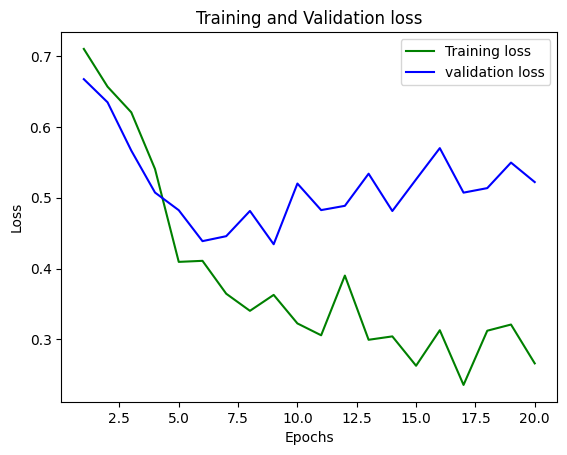

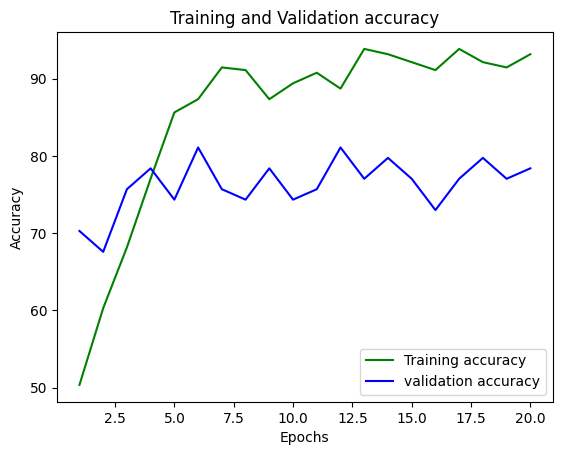

[[30  7]
 [ 9 28]]
True positive =  30
False positive =  7
False negative =  9
True negative =  28




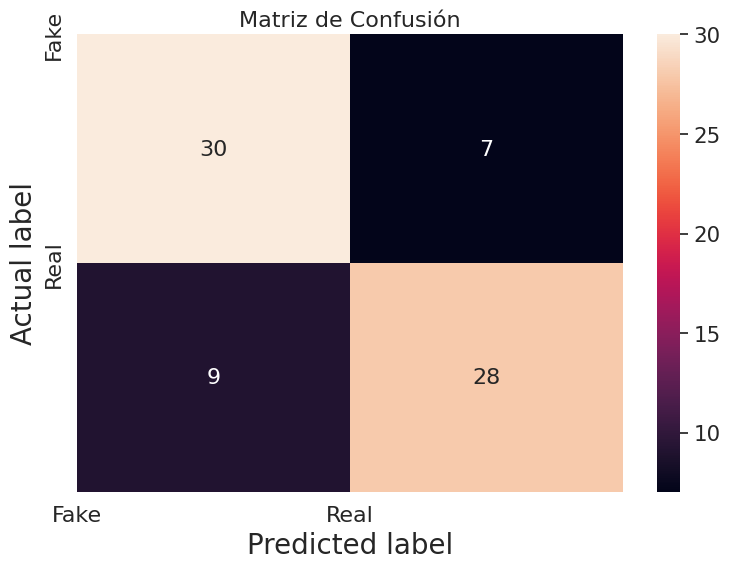

Calculated Accuracy 78.37837837837837


In [ ]:
from sklearn.metrics import confusion_matrix
#learning rate
lr = 1e-5#0.001
#number of epochs
num_epochs = 20

optimizer = torch.optim.Adam(model.parameters(), lr= lr,weight_decay = 1e-5)

#class_weights = torch.from_numpy(np.asarray([1,15])).type(torch.FloatTensor).cuda()
#criterion = nn.CrossEntropyLoss(weight = class_weights).cuda()
criterion = nn.CrossEntropyLoss().cuda()
train_loss_avg =[]
train_accuracy = []
test_loss_avg = []
test_accuracy = []
final_true = []
final_pred = []
final_outputs_logits = []

for epoch in range(1,num_epochs+1):
    l, acc = train_epoch(epoch,num_epochs,train_loader,model,criterion,optimizer)
    train_loss_avg.append(l)
    train_accuracy.append(acc)
    current_true, current_pred, current_outputs_logits, tl, t_acc = test(epoch,model,valid_loader,criterion) # Updated call
    test_loss_avg.append(tl)
    test_accuracy.append(t_acc)
    if epoch == num_epochs: # Store results from the last epoch
        final_true = current_true
        final_pred = current_pred
        final_outputs_logits = current_outputs_logits

plot_loss(train_loss_avg,test_loss_avg,len(train_loss_avg))
plot_accuracy(train_accuracy,test_accuracy,len(train_accuracy))
print(confusion_matrix(final_true,final_pred)) # Use final_true, final_pred
print_confusion_matrix(final_true,final_pred) # Corrected function name

## Métricas y Curvas Adicionales

F1 Score: 0.7778
Precision: 0.8000
Recall: 0.7568


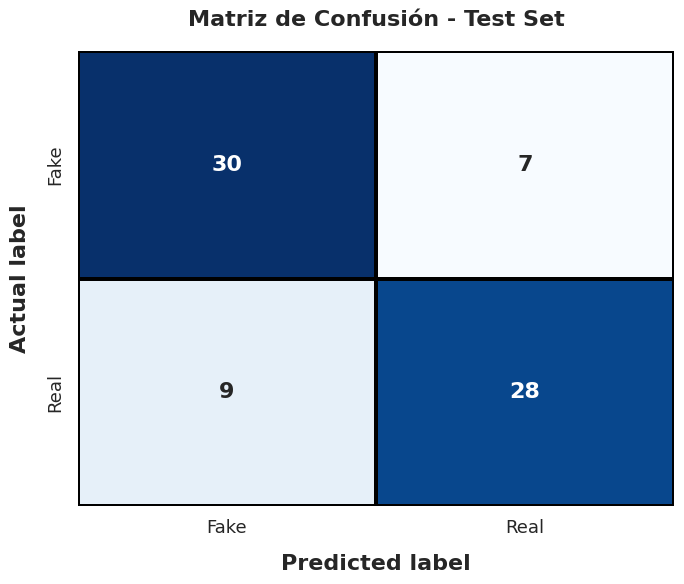

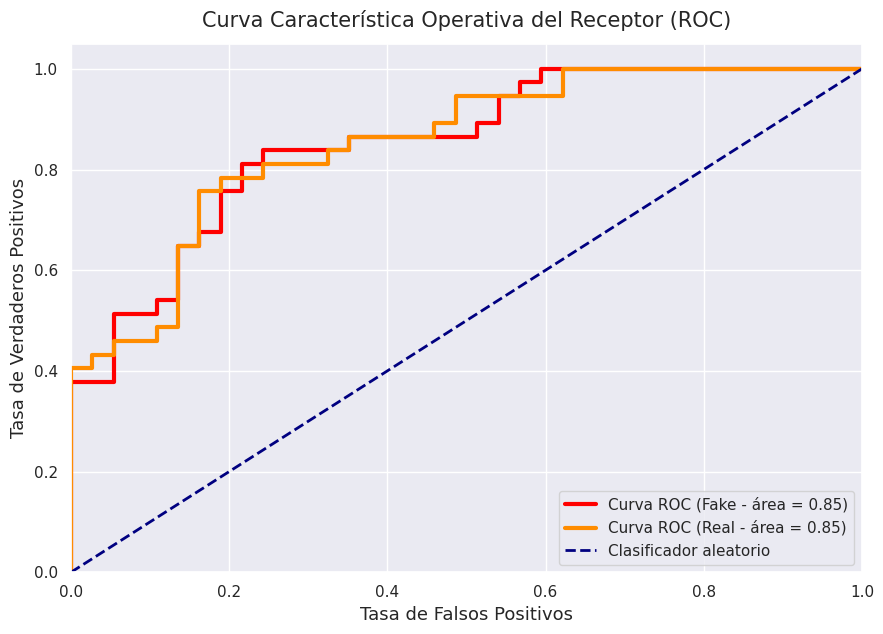

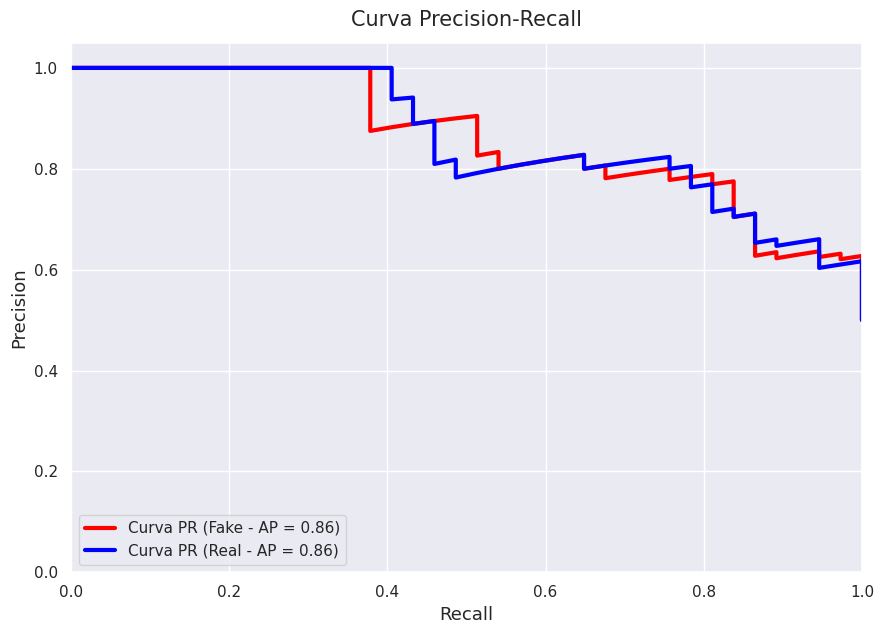

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_curve, auc, precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt
import torch.nn.functional as F
import seaborn as sns
import numpy as np

# 1. Calcular y mostrar métricas globales de clasificación en consola
f1 = f1_score(final_true, final_pred)
precision = precision_score(final_true, final_pred)
recall = recall_score(final_true, final_pred)

print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Nombres de las clases en el orden correcto de tu script (0: Fake, 1: Real)
class_names = ['Fake', 'Real']

# =====================================================================
# MATRIZ DE CONFUSIÓN (Estética limpia, solo valores enteros)
# =====================================================================
cm = confusion_matrix(final_true, final_pred)

plt.figure(figsize=(7, 6))
sns.set(style="white") # Fondo blanco para mantener la estética limpia y clara

# Generar el mapa de calor mostrando exclusivamente los enteros (fmt='d')
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                 xticklabels=class_names, yticklabels=class_names,
                 annot_kws={"size": 16, "weight": "bold"}, # Números internos destacados
                 linewidths=1.5, linecolor='black') # Bordes definidos entre cuadrantes

ax.set_ylabel('Actual label', size=16, weight='bold', labelpad=12)
ax.set_xlabel('Predicted label', size=16, weight='bold', labelpad=12)
plt.title('Matriz de Confusión - Test Set', fontsize=16, pad=18, weight='bold')

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.ylim([2, 0]) # Mantiene la corrección de límites de tu script original
plt.tight_layout()
plt.savefig('/content/mat.png', dpi=300) # Guarda el gráfico optimizado
plt.show()

# Convertir tus logits reales a probabilidades para ambas clases
probabilities_all = F.softmax(torch.tensor(final_outputs_logits), dim=1).numpy()
probabilities_fake = probabilities_all[:, 0] # Probabilities for class 0 (Fake)
probabilities_real = probabilities_all[:, 1] # Probabilities for class 1 (Real)

# =====================================================================
# CURVA ROC
# =====================================================================
# For 'Fake' class (label 0)
fpr_fake, tpr_fake, _ = roc_curve(final_true, probabilities_fake, pos_label=0)
roc_auc_fake = auc(fpr_fake, tpr_fake)

# For 'Real' class (label 1)
fpr_real, tpr_real, _ = roc_curve(final_true, probabilities_real, pos_label=1)
roc_auc_real = auc(fpr_real, tpr_real)

plt.figure(figsize=(9, 6.5))
sns.set(style="darkgrid") # Retorna el estilo de cuadrícula para las curvas analíticas

plt.plot(fpr_fake, tpr_fake, color='red', lw=3, label=f'Curva ROC (Fake - área = {roc_auc_fake:.2f})')
plt.plot(fpr_real, tpr_real, color='darkorange', lw=3, label=f'Curva ROC (Real - área = {roc_auc_real:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos', fontsize=13)
plt.ylabel('Tasa de Verdaderos Positivos', fontsize=13)
plt.title('Curva Característica Operativa del Receptor (ROC)', fontsize=15, pad=12)
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.savefig('/content/curvaroc.png', dpi=300)
plt.show()

# =====================================================================
# CURVA PRECISION-RECALL (PR)
# =====================================================================
# For 'Fake' class (label 0)
precision_fake_curve, recall_fake_curve, _ = precision_recall_curve(final_true, probabilities_fake, pos_label=0)
ap_fake = auc(recall_fake_curve, precision_fake_curve)

# For 'Real' class (label 1)
precision_real_curve, recall_real_curve, _ = precision_recall_curve(final_true, probabilities_real, pos_label=1)
ap_real = auc(recall_real_curve, precision_real_curve)

plt.figure(figsize=(9, 6.5))
plt.plot(recall_fake_curve, precision_fake_curve, color='red', lw=3, label=f'Curva PR (Fake - AP = {ap_fake:.2f})')
plt.plot(recall_real_curve, precision_real_curve, color='blue', lw=3, label=f'Curva PR (Real - AP = {ap_real:.2f})')
plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('Curva Precision-Recall', fontsize=15, pad=12)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.legend(loc="lower left", fontsize=11)
plt.tight_layout()
plt.savefig('/content/curvapr.png', dpi=300)
plt.show()